In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from mpl_toolkits.mplot3d import Axes3D 

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

file_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path,encoding="Unicode_escape")

print(f"Xam dataset: {df.shape[0]:,} sətir, {df.shape[1]} sütun")

Xam dataset: 7,043 sətir, 21 sütun


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isna().sum()
print(f"TotalCharges-da boş (NaN) dəyər sayı: {n_missing}")

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"Silindikdən sonra: {df.shape[0]:,} sətir")

df.head()

TotalCharges-da boş (NaN) dəyər sayı: 11
Silindikdən sonra: 7,032 sətir


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})
overall_churn = df['Churn_Binary'].mean() * 100
print(f"Ümumi churn nisbəti: {overall_churn:.2f}%")
print(f"Churn edən müştəri sayı: {df['Churn_Binary'].sum():,} / {len(df):,}")

Ümumi churn nisbəti: 26.58%
Churn edən müştəri sayı: 1,869 / 7,032


In [9]:
segment_cols = ['Contract', 'PaymentMethod', 'InternetService', 'SeniorCitizen']
for col in segment_cols:
    print(f"--- {col} ---")
    result = (df.groupby(col)['Churn_Binary'].mean() * 100).round(2).sort_values(ascending=False)
    counts = df[col].value_counts()
    summary = pd.DataFrame({'Churn_Rate_%': result, 'Customer_Count': counts})
    print(summary)
    print()

--- Contract ---
                Churn_Rate_%  Customer_Count
Contract                                    
Month-to-month         42.71            3875
One year               11.28            1472
Two year                2.85            1685

--- PaymentMethod ---
                           Churn_Rate_%  Customer_Count
PaymentMethod                                          
Electronic check                  45.29            2365
Mailed check                      19.20            1604
Bank transfer (automatic)         16.73            1542
Credit card (automatic)           15.25            1521

--- InternetService ---
                 Churn_Rate_%  Customer_Count
InternetService                              
Fiber optic             41.89            3096
DSL                     19.00            2416
No                       7.43            1520

--- SeniorCitizen ---
               Churn_Rate_%  Customer_Count
SeniorCitizen                              
0                     23.65      

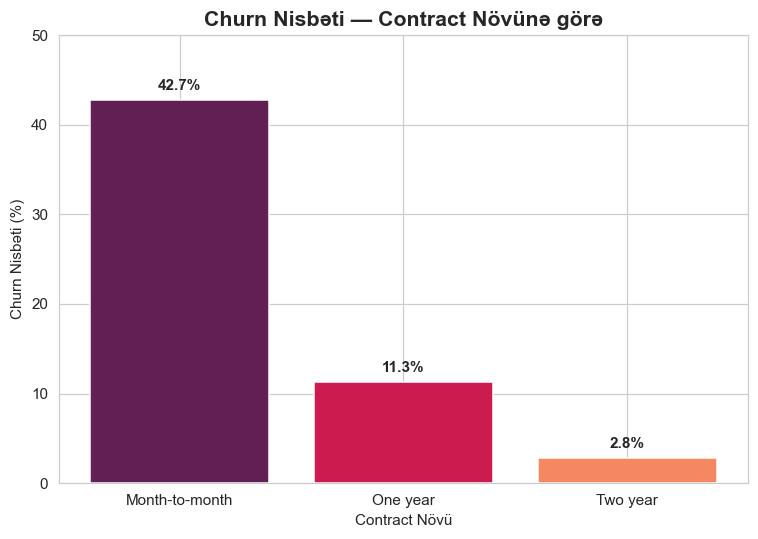

In [10]:
contract_churn = (df.groupby('Contract')['Churn_Binary'].mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette('rocket', len(contract_churn))
bars = ax.bar(contract_churn.index, contract_churn.values, color=colors, edgecolor='white')
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Churn Nisbəti — Contract Növünə görə', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Növü')
ax.set_ylabel('Churn Nisbəti (%)')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

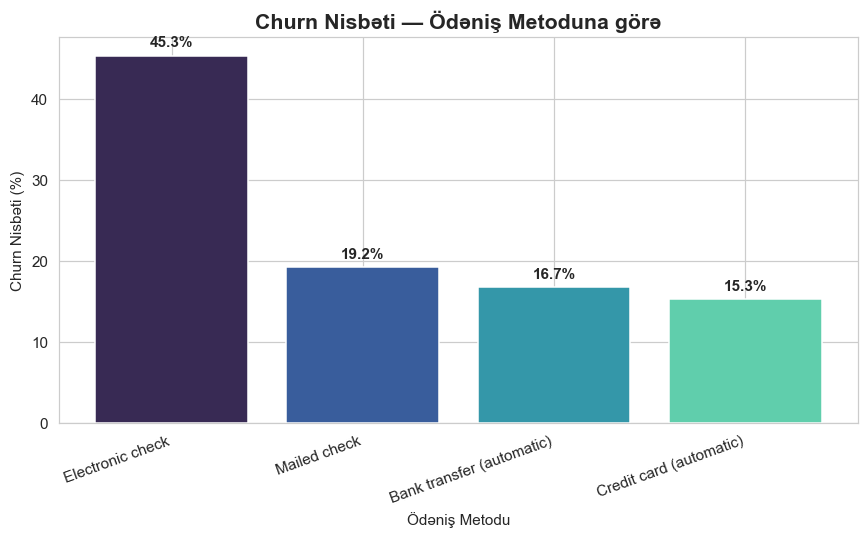

In [11]:
payment_churn = (df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('mako', len(payment_churn))
bars = ax.bar(payment_churn.index, payment_churn.values, color=colors, edgecolor='white')

for bar, val in zip(bars, payment_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Churn Nisbəti — Ödəniş Metoduna görə', fontsize=14, fontweight='bold')
ax.set_xlabel('Ödəniş Metodu')
ax.set_ylabel('Churn Nisbəti (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
bins = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)
tenure_churn = (df.groupby('TenureGroup', observed=True)['Churn_Binary'].mean() * 100).round(2)
tenure_counts = df['TenureGroup'].value_counts().reindex(labels)
tenure_summary = pd.DataFrame({'Churn_Rate_%': tenure_churn.reindex(labels), 'Customer_Count': tenure_counts})
tenure_summary


,Churn_Rate_%,Customer_Count
TenureGroup,,
0-12,47.68,2175
13-24,28.71,1024
25-48,20.39,1594
49-72,9.51,2239


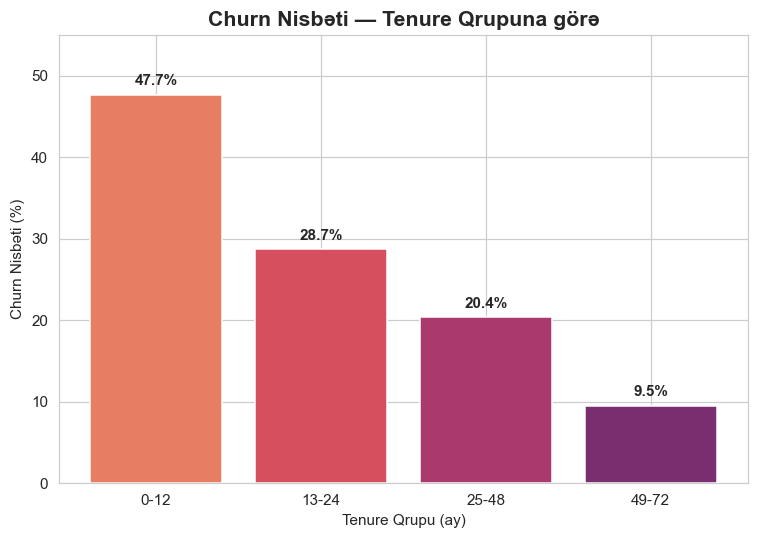

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette('flare', len(labels))
bars = ax.bar(labels, tenure_churn.reindex(labels).values, color=colors, edgecolor='white')

for bar, val in zip(bars, tenure_churn.reindex(labels).values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Churn Nisbəti — Tenure Qrupuna görə', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Qrupu (ay)')
ax.set_ylabel('Churn Nisbəti (%)')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.savefig('churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
charges_comparison = df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median', 'std']).round(2)
print("MonthlyCharges — Churned vs Non-Churned:")
print(charges_comparison)
df['HighCharge'] = df['MonthlyCharges'] > 65
high_charge_churn = (df.groupby('HighCharge')['Churn_Binary'].mean() * 100).round(2)
print()
print("Churn nisbəti — MonthlyCharges > \$65 olanlar vs olmayanlar:")
print(high_charge_churn)

MonthlyCharges — Churned vs Non-Churned:
        mean  median    std
Churn                      
No     61.31   64.45  31.09
Yes    74.44   79.65  24.67

Churn nisbəti — MonthlyCharges > \$65 olanlar vs olmayanlar:
HighCharge
False    16.43
True     34.74
Name: Churn_Binary, dtype: float64


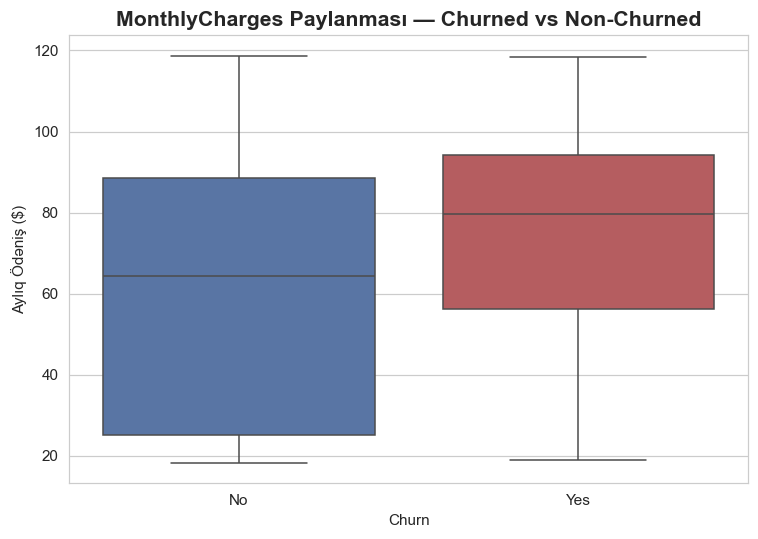

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False, ax=ax)
ax.set_title('MonthlyCharges Paylanması — Churned vs Non-Churned', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Aylıq Ödəniş ($)')
plt.tight_layout()
plt.savefig('monthly_charges_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
risk_profiles = df.groupby(['Contract', 'InternetService', 'PaymentMethod'])['Churn_Binary'].agg(
    Churn_Rate=('mean'), Customer_Count=('count')
).reset_index()
risk_profiles['Churn_Rate_%'] = (risk_profiles['Churn_Rate'] * 100).round(2)
risk_profiles_reliable = risk_profiles[risk_profiles['Customer_Count'] >= 30].sort_values(
    'Churn_Rate_%', ascending=False
)
top3 = risk_profiles_reliable[['Contract', 'InternetService', 'PaymentMethod', 'Customer_Count', 'Churn_Rate_%']].head(3)
top3

,Contract,InternetService,PaymentMethod,Customer_Count,Churn_Rate_%
6,Month-to-month,Fiber optic,Electronic check,1307,60.37
7,Month-to-month,Fiber optic,Mailed check,201,50.75
4,Month-to-month,Fiber optic,Bank transfer (automatic),327,45.57


InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   32.22        54.61  18.89
One year          9.30        19.29   2.48
Two year          1.93         7.23   0.79


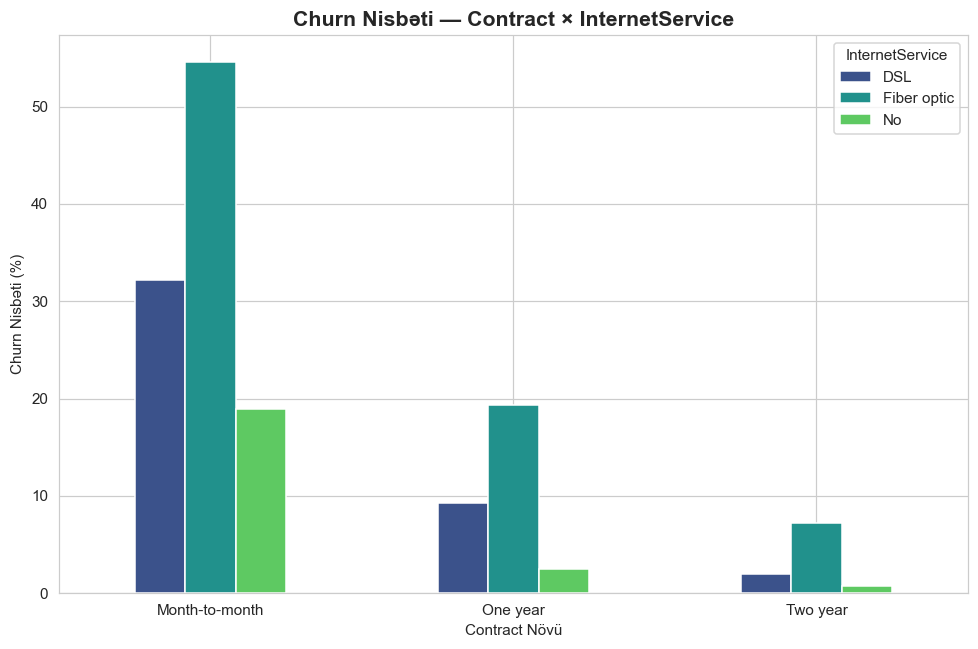

In [17]:
pivot_ci = df.groupby(['Contract', 'InternetService'])['Churn_Binary'].mean().unstack() * 100
print(pivot_ci.round(2))
fig, ax = plt.subplots(figsize=(9, 6))
pivot_ci.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', 3), edgecolor='white')
ax.set_title('Churn Nisbəti — Contract × InternetService', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Növü')
ax.set_ylabel('Churn Nisbəti (%)')
ax.legend(title='InternetService')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_contract_x_internet.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
avg_tenure = df.groupby(['Contract', 'Churn'])['tenure'].mean().round(1).unstack()
avg_tenure

Churn,No,Yes
Contract,,
Month-to-month,21.0,14.0
One year,41.7,45.0
Two year,56.9,61.3
